# Analisis dan Pemodelan Prediksi Kawasan Kumuh (Slum) Berdasarkan Indikator Bangunan

Notebook ini dibuat untuk melakukan klasifikasi area *Slum* (1) dan *Non-Slum* (0) menggunakan algoritma **XGBoost**.

### Aturan Utama:
1. **Indikator Tunggal:** Hanya menggunakan fitur-fitur yang berkaitan dengan karakteristik **bangunan**.
2. **Pencegahan Data Leakage:** Semua proses transformasi data (*scaling*, *encoding*) dibungkus di dalam `Pipeline` Scikit-Learn dan dipisahkan secara ketat setelah tahapan *Data Splitting*.

## 1. Import Library yang Dibutuhkan

In [11]:
# Pastikan library berikut sudah terinstall di lingkungan Anda
# !pip install xgboost shap scikit-learn seaborn matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from xgboost import XGBClassifier
import shap

import warnings
warnings.filterwarnings('ignore')

## 2. Data Loading & Penyaringan Fitur (Hanya Karakteristik Bangunan)

In [12]:
# Load dataset
df = pd.read_csv('../data/processed/features_buildings.csv')

# Memilih kolom yang HANYA berkaitan dengan indikator bangunan + target dan identitas kota
building_columns = [
    'b_area_mean', 'b_area_median', 'b_area_std', 'b_area_sum',
    'b_count', 'b_coverage', 'b_density_km2', 'b_size_cv',
    'building_fractional_count_mean', 'building_fractional_count_stdDev',
    'building_height_mean', 'building_height_stdDev',
    'building_presence_mean', 'building_presence_stdDev',
    'city', 'slum'
]

df_build = df[building_columns].copy()
print(f"Dimensi data setelah pemfilteran indikator: {df_build.shape}")
df_build.head()

Dimensi data setelah pemfilteran indikator: (828, 16)


,b_area_mean,b_area_median,b_area_std,b_area_sum,b_count,b_coverage,b_density_km2,b_size_cv,building_fractional_count_mean,building_fractional_count_stdDev,building_height_mean,building_height_stdDev,building_presence_mean,building_presence_stdDev,city,slum
0,84.014185,67.791976,74.064580,350003.094138,4166,0.063958,761.273292,0.881572,0.000251,0.000721,0.565792,1.447128,0.059435,0.154040,ambon,0
1,79.583531,59.188367,76.755470,68998.921130,867,0.061616,774.232211,0.964464,0.000241,0.000716,0.500697,1.349396,0.055179,0.149881,ambon,0
2,93.658193,71.880049,111.397354,190500.764170,2034,0.021924,234.086584,1.189403,0.000072,0.000383,0.189191,0.940635,0.019553,0.093794,ambon,0
3,87.579051,78.277357,72.664686,21369.288536,244,0.042073,480.395608,0.829704,0.000175,0.000616,0.558317,1.815798,0.039945,0.126711,ambon,0
4,89.203578,74.166671,73.209063,23817.355406,267,0.006805,76.288870,0.820696,0.000028,0.000250,0.077482,0.637471,0.006337,0.050900,ambon,0


## 3. Exploratory Data Analysis (EDA)
Melakukan analisis visual terhadap sebaran target, kepadatan bangunan, serta hubungannya dengan dimensi bangunan.

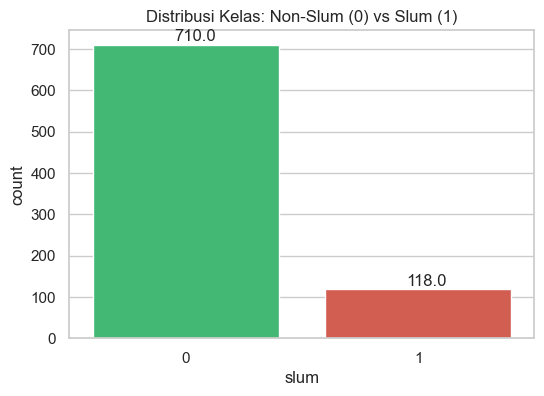

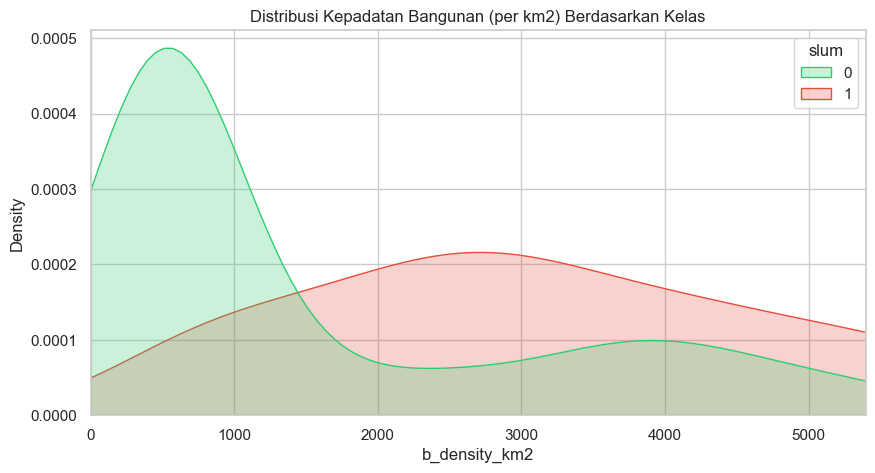

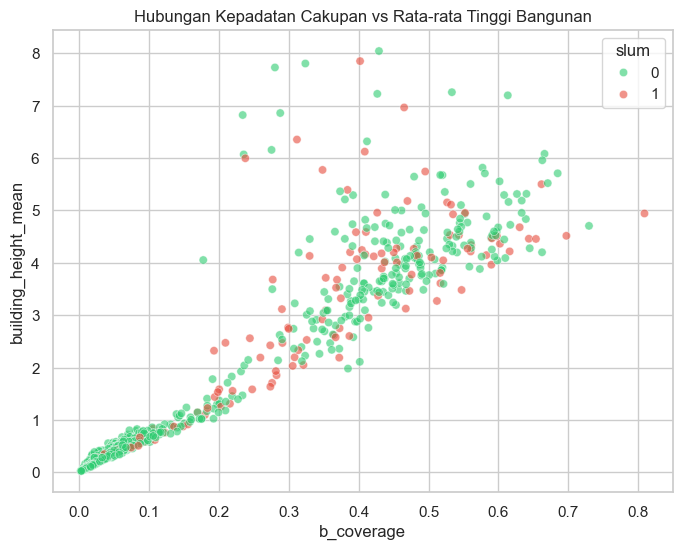

In [13]:
sns.set_theme(style="whitegrid")

# Graf 1: Distribusi Kelas Target (Slum vs Non-Slum)
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df_build, x='slum', palette=['#2ecc71', '#e74c3c'])
plt.title('Distribusi Kelas: Non-Slum (0) vs Slum (1)')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x()+0.35, p.get_height()+10))
plt.show()

# Graf 2: Analisis Densitas Kepadatan Bangunan (b_density_km2)
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df_build, x='b_density_km2', hue='slum', fill=True, common_norm=False, palette=['#2ecc71', '#e74c3c'])
plt.title('Distribusi Kepadatan Bangunan (per km2) Berdasarkan Kelas')
plt.xlim(0, df_build['b_density_km2'].quantile(0.95)) 
plt.show()

# Graf 3: Keterkaitan antara Cakupan Wilayah (Coverage) dan Tinggi Bangunan
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_build, x='b_coverage', y='building_height_mean', hue='slum', alpha=0.6, palette=['#2ecc71', '#e74c3c'])
plt.title('Hubungan Kepadatan Cakupan vs Rata-rata Tinggi Bangunan')
plt.show()

## 4. Preprocessing & Data Splitting (Anti Data Leakage)
Pemisahan data dilakukan terlebih dahulu. Parameter kalkulasi fitur (seperti mean/std pada scaler) murni hanya dipelajari dari `X_train` untuk menghindari kebocoran informasi (*data leakage*).

In [14]:
X = df_build.drop(columns=['slum'])
y = df_build['slum']

# Menggunakan stratify=y karena distribusi target yang tidak seimbang (imbalanced)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah Data Latih (Train): {X_train.shape[0]} baris")
print(f"Jumlah Data Uji (Test)  : {X_test.shape[0]} baris")

# Identifikasi tipe kolom
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = ['city']

# Rekayasa Pipeline Pengolah Data
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])

Jumlah Data Latih (Train): 662 baris
Jumlah Data Uji (Test)  : 166 baris


## 5. Pemodelan & Hyperparameter Tuning (XGBoost)
Menghitung rasio kelas untuk menangani ketidakseimbangan data menggunakan parameter `scale_pos_weight` pada model XGBoost, dilanjutkan dengan pencarian parameter optimal via `RandomizedSearchCV`.

In [15]:
# Rasio pembobotan kelas minoritas
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

xgb_base = XGBClassifier(
    scale_pos_weight=ratio,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42
)

# Memasukkan preprocessor dan model ke dalam satu Pipeline Utuh
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb_base)
])

# Definisi ruang hyperparameter
param_distributions = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__subsample': [0.7, 0.8, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 1.0]
}

tuned_search = RandomizedSearchCV(
    full_pipeline,
    param_distributions=param_distributions,
    n_iter=15,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Memulai pencarian hyperparameter terbaik...")
tuned_search.fit(X_train, y_train)

print(f"\nParameter Terbaik: {tuned_search.best_params_}")
print(f"Skor Validasi Terbaik (ROC-AUC): {tuned_search.best_score_:.4f}")

best_model_pipeline = tuned_search.best_estimator_

Memulai pencarian hyperparameter terbaik...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Parameter Terbaik: {'classifier__subsample': 0.7, 'classifier__n_estimators': 100, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.7}
Skor Validasi Terbaik (ROC-AUC): 0.8308


## 6. Evaluasi Hasil Model

=== Laporan Klasifikasi Data Uji ===
              precision    recall  f1-score   support

           0       0.87      0.88      0.88       142
           1       0.26      0.25      0.26        24

    accuracy                           0.79       166
   macro avg       0.57      0.57      0.57       166
weighted avg       0.79      0.79      0.79       166



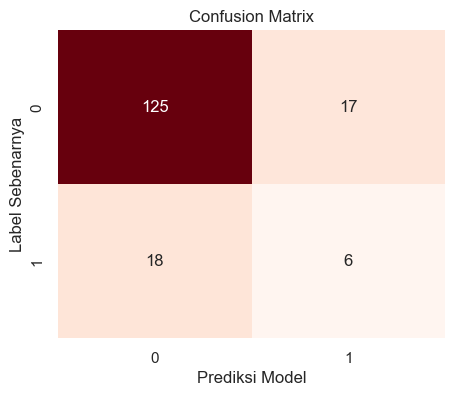

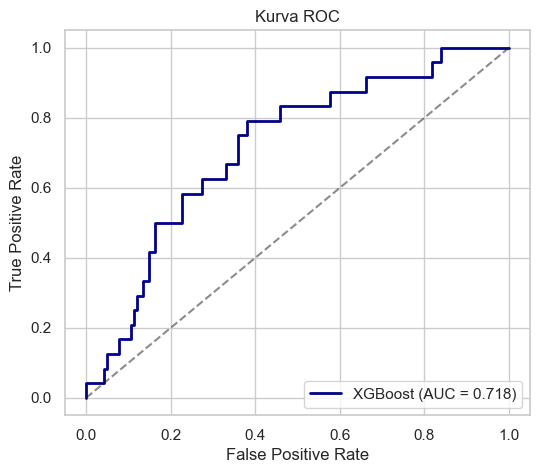

In [16]:
y_pred = best_model_pipeline.predict(X_test)
y_pred_proba = best_model_pipeline.predict_proba(X_test)[:, 1]

# 1. Laporan Klasifikasi
print("=== Laporan Klasifikasi Data Uji ===")
print(classification_report(y_test, y_pred))

# 2. Confusion Matrix Heatmap
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Prediksi Model')
plt.ylabel('Label Sebenarnya')
plt.show()

# 3. Kurva ROC-AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {auc_score:.3f})', color='darkblue', lw=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Kurva ROC')
plt.legend(loc='lower right')
plt.show()

## 7. Interpretabilitas Model (Feature Importance & SHAP)
Membongkar keputusan model untuk melihat fitur bangunan mana yang paling berpengaruh signifikan.

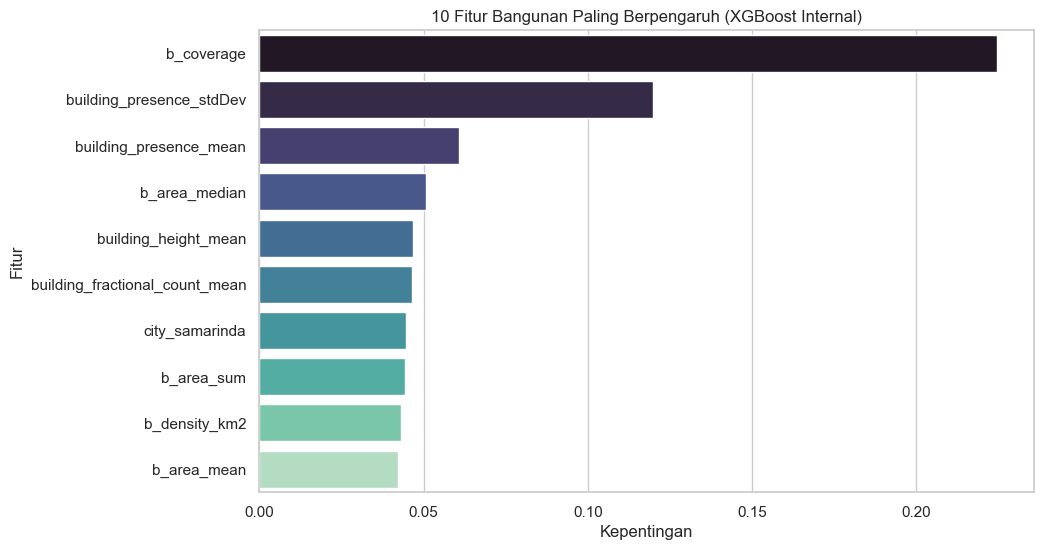


--- Mengkalkulasi SHAP Values ---


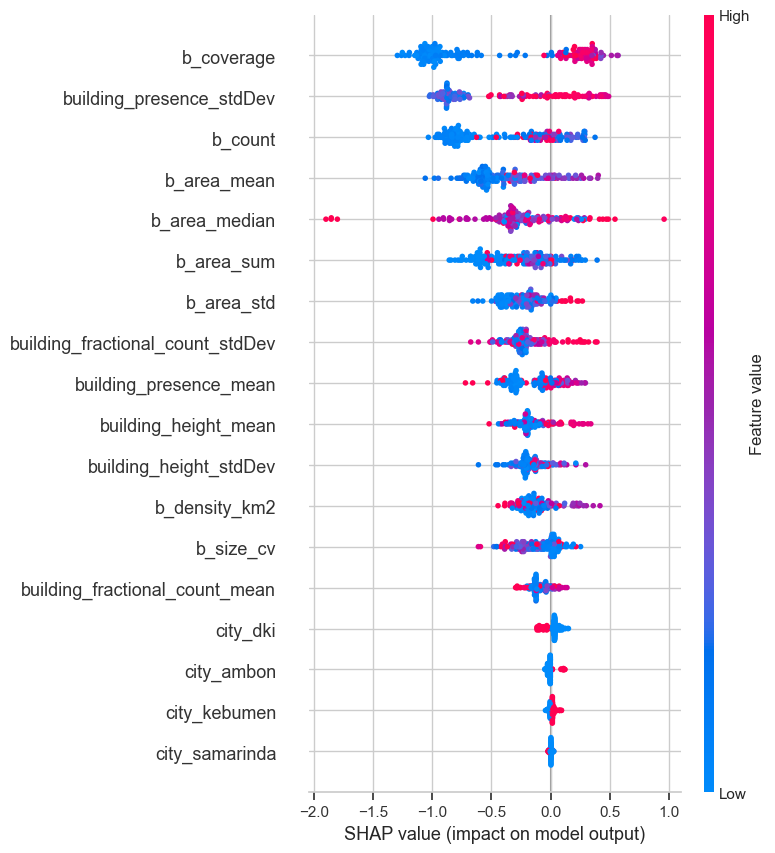

In [17]:
# Ekstraksi nama fitur setelah melewati proses Pipeline
cat_encoder = best_model_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_features = cat_encoder.get_feature_names_out(cat_cols).tolist()
feature_names_final = num_cols + cat_features

xgb_internal_model = best_model_pipeline.named_steps['classifier']

# Global Importance bawaan XGBoost
importances = xgb_internal_model.feature_importances_
df_importance = pd.DataFrame({'Fitur': feature_names_final, 'Kepentingan': importances}).sort_values('Kepentingan', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Kepentingan', y='Fitur', data=df_importance.head(10), palette='mako')
plt.title('10 Fitur Bangunan Paling Berpengaruh (XGBoost Internal)')
plt.show()

# Analisis Dampak Fitur Menggunakan SHAP
print("\n--- Mengkalkulasi SHAP Values ---")
X_test_transformed = best_model_pipeline.named_steps['preprocessor'].transform(X_test)

explainer = shap.TreeExplainer(xgb_internal_model)
shap_vals = explainer.shap_values(X_test_transformed)

plt.figure()
shap.summary_plot(shap_vals, X_test_transformed, feature_names=feature_names_final)

## 8. Pipeline Inferensi (Prediksi Data Baru)

In [18]:
def prediksikan_area_baru(df_baru, model_pipeline):
    """
    Fungsi siap pakai untuk menerima data baru dengan struktur kolom yang sama
    dan mengeluarkan hasil prediksi probabilitas serta kelasnya.
    """
    pred_class = model_pipeline.predict(df_baru)
    pred_proba = model_pipeline.predict_proba(df_baru)[:, 1]
    
    df_hasil = df_baru.copy()
    df_hasil['Prediksi_Status_Slum'] = pred_class
    df_hasil['Probabilitas_Slum'] = pred_proba
    return df_hasil

# Pengujian inferensi menggunakan beberapa baris dari data uji
contoh_data_baru = X_test.head(4).copy()
hasil_prediksi_akhir = prediksikan_area_baru(contoh_data_baru, best_model_pipeline)

hasil_prediksi_akhir[['city', 'b_density_km2', 'building_height_mean', 'Prediksi_Status_Slum', 'Probabilitas_Slum']]

,city,b_density_km2,building_height_mean,Prediksi_Status_Slum,Probabilitas_Slum
509,kebumen,480.945729,0.310480,0,0.006836
545,kebumen,1766.352362,1.305267,1,0.811269
548,kebumen,299.917249,0.255220,0,0.032756
168,dki,4666.284174,3.652534,0,0.294300
